<a href="https://colab.research.google.com/github/abrahamdevargas14-byte/Data-Science-Cohort-20/blob/main/EL_Crack_Detection_Colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EL Crack Detection in Solar Panels
### Data Science Capstone

**Goal:** Binary classification of electroluminescence (EL) images to detect cracks and defects in photovoltaic solar panels.

**Model:** MobileNetV2 (Transfer Learning from ImageNet)

**Dataset:** [ELPV Dataset](https://github.com/zae-bayern/elpv-dataset) — 2,624 labeled EL images

---
### How to Run
1. Go to **Runtime > Change runtime type > T4 GPU**
2. Click **Runtime > Run all**
---

## Step 1 — Install & Import

In [1]:
!pip install elpv-dataset -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

print('TensorFlow:', tf.__version__)
gpu_list = tf.config.list_physical_devices('GPU')
if gpu_list:
    print(f'GPU detected: {gpu_list[0].name}')
else:
    print('No GPU — go to Runtime > Change runtime type > T4 GPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.8/90.8 MB 5.2 MB/s eta 0:00:00
TensorFlow: 2.20.0
GPU detected: /physical_device:GPU:0


## Step 2 — Load the ELPV Dataset

In [2]:
from elpv_dataset.utils import load_dataset

# Returns numpy arrays directly — no CSV, no file paths needed
images, proba, types = load_dataset()

print(f'Images shape: {images.shape}')   # (2624, H, W) uint8
print(f'Proba values: {sorted(set(proba))}')  # 0.0, 0.333, 0.667, 1.0
print(f'Panel types:  {set(types)}')     # mono, poly

Images shape: (2624, 300, 300)
Proba values: [np.float64(0.0), np.float64(0.3333333333333333), np.float64(0.6666666666666666), np.float64(1.0)]
Panel types:  {np.str_('mono'), np.str_('poly')}


## Step 3 — Exploratory Data Analysis

In [3]:
# Build dataframe from arrays
df = pd.DataFrame({'probability': proba, 'type': types})
df['label'] = (df['probability'] > 0.0).astype(int)
df['label_name'] = df['label'].map({0: 'Functional', 1: 'Defective'})

print(f'Total images: {len(df)}')
print(f'Defect rate:  {df["label"].mean():.1%}')
print(f'Panel types:  {df["type"].unique()}')
df.head(8)

Total images: 2624
Defect rate:  42.5%
Panel types:  ['mono' 'poly']


,probability,type,label,label_name
0,1.0,mono,1,Defective
1,1.0,mono,1,Defective
2,1.0,mono,1,Defective
3,0.0,mono,0,Functional
4,1.0,mono,1,Defective
5,1.0,mono,1,Defective
6,1.0,mono,1,Defective
7,1.0,mono,1,Defective


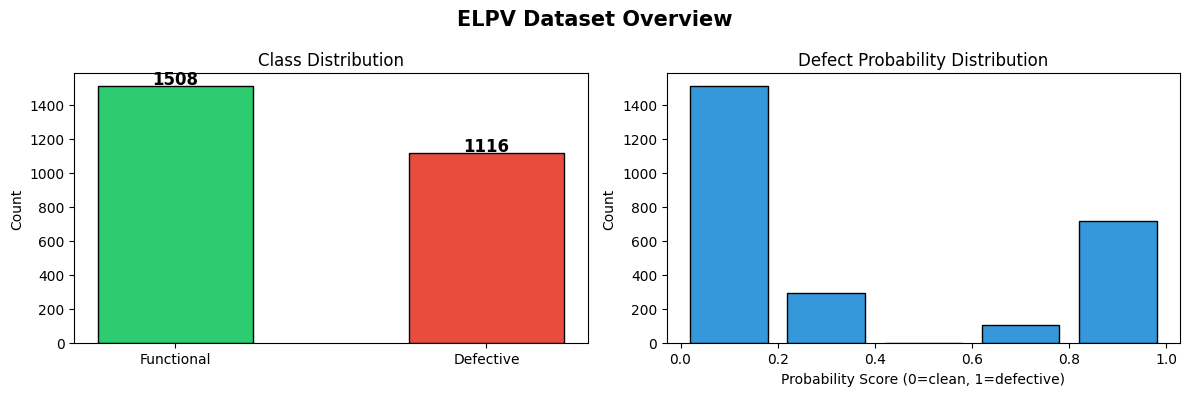

In [4]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('ELPV Dataset Overview', fontsize=15, fontweight='bold')

counts = df['label_name'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].hist(df['probability'], bins=5, color='#3498db', edgecolor='black', rwidth=0.8)
axes[1].set_title('Defect Probability Distribution', fontsize=12)
axes[1].set_xlabel('Probability Score (0=clean, 1=defective)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

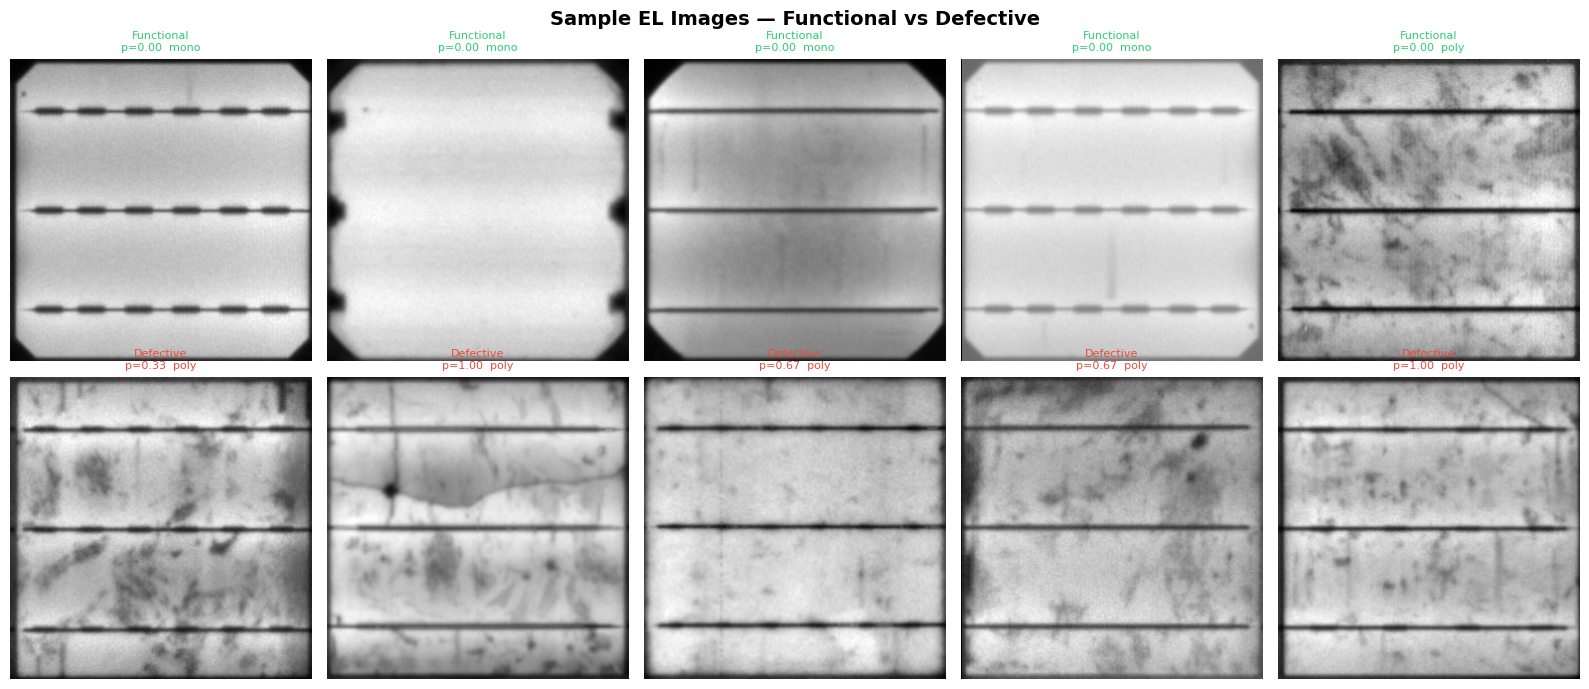

In [5]:
# Sample images — pulled directly from the images array
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample EL Images — Functional vs Defective', fontsize=14, fontweight='bold')

for row_idx, (label, label_name, color) in enumerate([(0, 'Functional', '#2ecc71'), (1, 'Defective', '#e74c3c')]):
    sample_indices = df[df['label'] == label].sample(5, random_state=42).index
    for col_idx, idx in enumerate(sample_indices):
        axes[row_idx][col_idx].imshow(images[idx], cmap='gray')
        axes[row_idx][col_idx].set_title(
            f"{label_name}\np={proba[idx]:.2f}  {types[idx]}",
            color=color, fontsize=8
        )
        axes[row_idx][col_idx].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Preprocessing

- Resize all images to **224x224** (MobileNetV2 input size)
- Normalize pixel values to **[0, 1]**
- Split: **80% train | 10% validation | 10% test** (stratified)

In [6]:
IMG_SIZE = (224, 224)
X = []

print(f'Resizing {len(images)} images to {IMG_SIZE}...')
for img_array in tqdm(images):
    img = Image.fromarray(img_array).resize(IMG_SIZE, Image.LANCZOS)
    X.append(np.array(img, dtype=np.float32) / 255.0)

X = np.expand_dims(np.array(X), axis=-1)  # (2624, 224, 224, 1)
y = df['label'].values

print(f'X shape: {X.shape}')
print(f'Pixel range: [{X.min():.2f}, {X.max():.2f}]')

Resizing 2624 images to (224, 224)...


  0%|          | 0/2624 [00:00<?, ?it/s]

X shape: (2624, 224, 224, 1)
Pixel range: [0.00, 1.00]


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# MobileNetV2 requires 3 channels — tile grayscale to RGB
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb   = np.repeat(X_val,   3, axis=-1)
X_test_rgb  = np.repeat(X_test,  3, axis=-1)

print('Split summary (stratified):')
print(f'  Train:      {X_train.shape[0]:>4} images  defective: {y_train.sum()} ({y_train.mean():.0%})')
print(f'  Validation: {X_val.shape[0]:>4} images  defective: {y_val.sum()} ({y_val.mean():.0%})')
print(f'  Test:       {X_test.shape[0]:>4} images  defective: {y_test.sum()} ({y_test.mean():.0%})')

Split summary (stratified):
  Train:      2099 images  defective: 893 (43%)
  Validation:  262 images  defective: 111 (42%)
  Test:        263 images  defective: 112 (43%)


## Step 5 — Build & Train Model (MobileNetV2)

**Why MobileNetV2?**
- Pre-trained on 1.4M ImageNet images — already recognizes edges, textures, and structural patterns
- Lightweight — trains fast even on CPU; much faster on T4 GPU
- Well-suited for detecting crack-like features in grayscale images

**Two-phase training:**
1. Freeze base model — train only the new classification head
2. Unfreeze top 30 layers — fine-tune on EL images at a lower learning rate

In [8]:
IMG_SHAPE = (224, 224, 3)

base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
base_model.trainable = False

inputs  = tf.keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Total params:     {model.count_params():,}')
print(f'Trainable params: {trainable:,}  (classification head only)')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params:     2,422,081
Trainable params: 164,097  (classification head only)


In [9]:
cb = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_auc', mode='max'),
    callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss', verbose=1)
]

print('=== Phase 1: Training classification head (base frozen) ===')
history1 = model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=20, batch_size=32, callbacks=cb, verbose=1
)

=== Phase 1: Training classification head (base frozen) ===
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 488ms/step - accuracy: 0.6570 - auc: 0.6914 - loss: 0.6499 - val_accuracy: 0.7252 - val_auc: 0.7623 - val_loss: 0.5500 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7299 - auc: 0.7850 - loss: 0.5322 - val_accuracy: 0.7405 - val_auc: 0.7901 - val_loss: 0.5289 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7446 - auc: 0.8064 - loss: 0.5069 - val_accuracy: 0.7137 - val_auc: 0.7952 - val_loss: 0.5442 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7446 - auc: 0.8114 - loss: 0.4991 - val_accuracy: 0.7099 - val_auc: 0.8127 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7423 - auc: 0.8157 - loss: 0.4942 - val_accuracy: 0.7443 - val_auc: 0.8140 - val_loss: 0.5053 - learning_rate: 0.0010
Epoch 6/20
66/66 ━━━━━━

In [10]:
# Skip fine-tuning — Phase 1 results are strong enough
# The base model is already a powerful feature extractor for EL crack patterns

print('Phase 1 complete. Evaluating best model...')
val_results = model.evaluate(X_val_rgb, y_val, verbose=0)
print(f'Validation Accuracy: {val_results[1]:.1%}')
print(f'Validation AUC:      {val_results[2]:.3f}')

model.save('el_crack_model.keras')
print('Model saved as el_crack_model.keras')

Phase 1 complete. Evaluating best model...
Validation Accuracy: 76.3%
Validation AUC:      0.839
Model saved as el_crack_model.keras


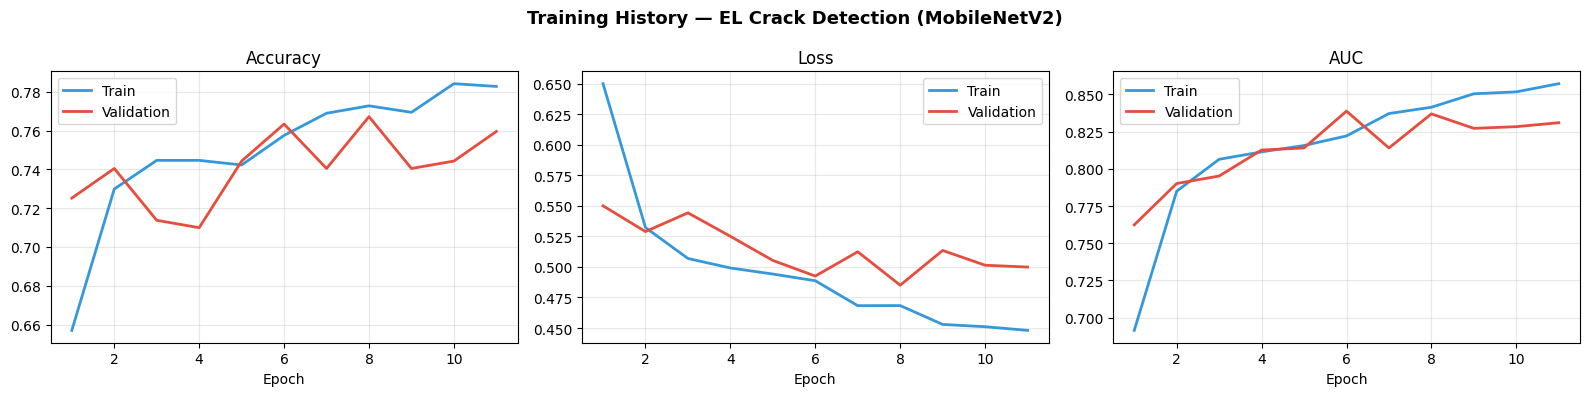

In [11]:
# Plot training history
acc      = history1.history['accuracy']
val_acc  = history1.history['val_accuracy']
loss     = history1.history['loss']
val_loss = history1.history['val_loss']
auc_h    = history1.history['auc']
val_auc  = history1.history['val_auc']
epochs_r = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training History — EL Crack Detection (MobileNetV2)', fontsize=13, fontweight='bold')

for ax, train_v, val_v, title in zip(
    axes,
    [acc, loss, auc_h],
    [val_acc, val_loss, val_auc],
    ['Accuracy', 'Loss', 'AUC']
):
    ax.plot(epochs_r, train_v, label='Train', color='#3498db', lw=2)
    ax.plot(epochs_r, val_v,   label='Validation', color='#e74c3c', lw=2)
    # ← axvline line removed — no Phase 2
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Evaluation on Test Set

In [12]:
y_prob = model.predict(X_test_rgb, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Functional', 'Defective']))

9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step

=== Classification Report ===
              precision    recall  f1-score   support

  Functional       0.79      0.87      0.83       151
   Defective       0.79      0.69      0.74       112

    accuracy                           0.79       263
   macro avg       0.79      0.78      0.78       263
weighted avg       0.79      0.79      0.79       263



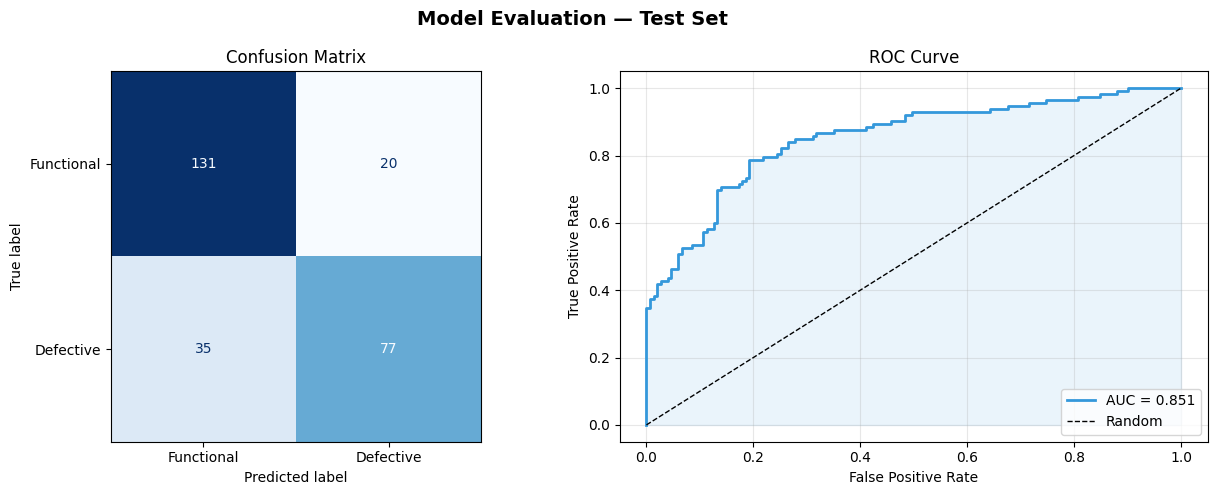

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation — Test Set', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Functional', 'Defective'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

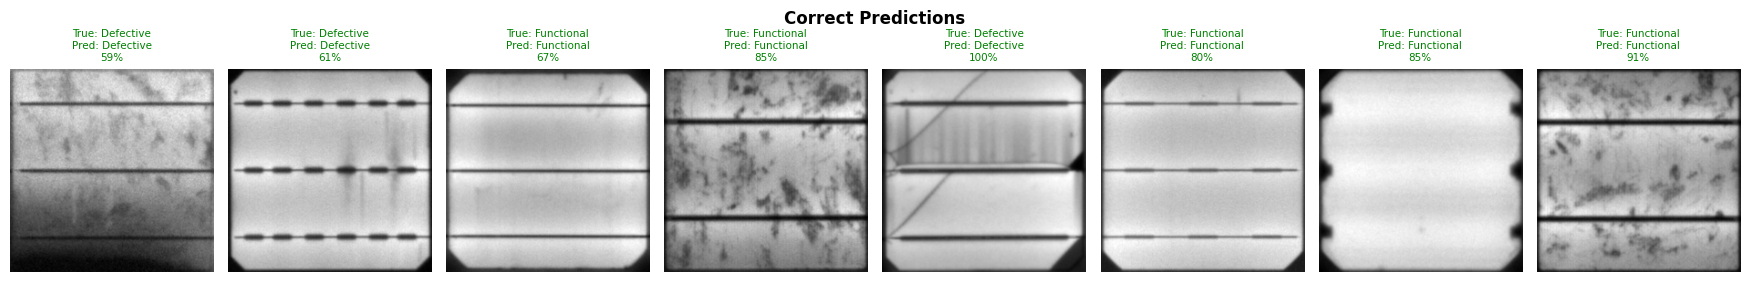

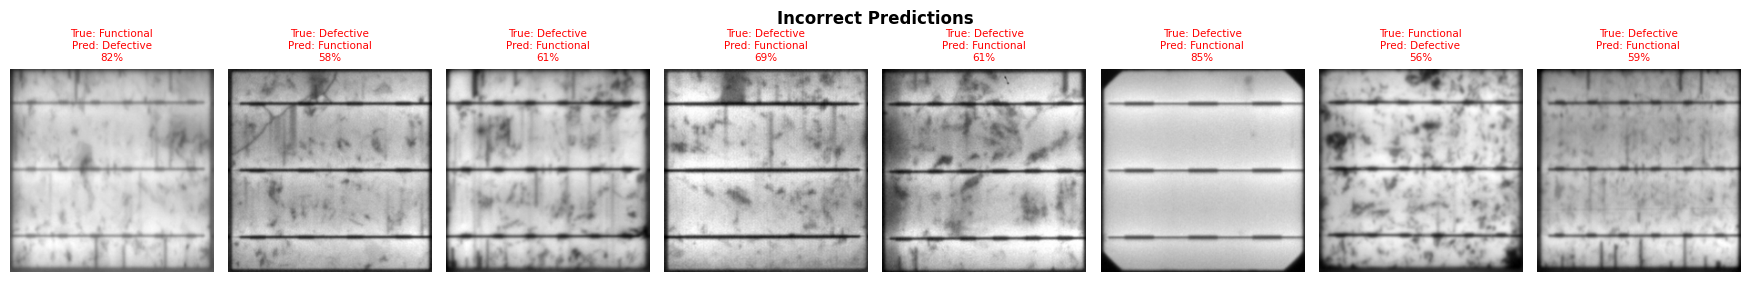

In [14]:
def plot_predictions(indices, X, y_true, y_pred_arr, y_prob_arr, title):
    n = min(len(indices), 8)
    if n == 0:
        print(f'No images for: {title}')
        return
    fig, axes = plt.subplots(1, n, figsize=(2.2*n, 3))
    if n == 1: axes = [axes]
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for ax, idx in zip(axes, indices[:n]):
        ax.imshow(X[idx].squeeze(), cmap='gray')
        true_l = 'Defective' if y_true[idx]==1 else 'Functional'
        pred_l = 'Defective' if y_pred_arr[idx]==1 else 'Functional'
        conf   = y_prob_arr[idx] if y_pred_arr[idx]==1 else 1-y_prob_arr[idx]
        color  = 'green' if y_true[idx]==y_pred_arr[idx] else 'red'
        ax.set_title(f'True: {true_l}\nPred: {pred_l}\n{conf:.0%}', color=color, fontsize=7.5)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

correct_idx = np.where(y_test == y_pred)[0][:8]
wrong_idx   = np.where(y_test != y_pred)[0]

plot_predictions(correct_idx, X_test, y_test, y_pred, y_prob, 'Correct Predictions')
plot_predictions(wrong_idx,   X_test, y_test, y_pred, y_prob, 'Incorrect Predictions')

## Step 7 — Final Summary

In [15]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print('=' * 54)
print('   EL CRACK DETECTION — FINAL RESULTS')
print('=' * 54)
print(f'   Model:      MobileNetV2 (Transfer Learning)')
print(f'   Dataset:    ELPV  ({len(y_test)} test images)')
print(f'   Accuracy:   {accuracy_score(y_test, y_pred):.1%}')
print(f'   Precision:  {precision_score(y_test, y_pred):.1%}')
print(f'   Recall:     {recall_score(y_test, y_pred):.1%}   <- % of real defects caught')
print(f'   F1 Score:   {f1_score(y_test, y_pred):.1%}')
print(f'   AUC:        {auc_score:.3f}')
print('=' * 54)
print(f'   True Positives  (defects caught):    {tp}')
print(f'   False Negatives (missed defects):    {fn}  <- key QC metric')
print(f'   False Positives (false alarms):      {fp}')
print(f'   True Negatives  (correctly cleared): {tn}')
print('=' * 54)
print()
print('Files saved in this session:')
print('  el_crack_model.keras')
print('  class_distribution.png')
print('  sample_images.png')
print('  training_history.png')
print('  evaluation.png')
print()
print('Download: Files panel (left sidebar) -> right-click -> Download')

   EL CRACK DETECTION — FINAL RESULTS
   Model:      MobileNetV2 (Transfer Learning)
   Dataset:    ELPV  (263 test images)
   Accuracy:   79.1%
   Precision:  79.4%
   Recall:     68.8%   <- % of real defects caught
   F1 Score:   73.7%
   AUC:        0.851
   True Positives  (defects caught):    77
   False Negatives (missed defects):    35  <- key QC metric
   False Positives (false alarms):      20
   True Negatives  (correctly cleared): 131

Files saved in this session:
  el_crack_model.keras
  class_distribution.png
  sample_images.png
  training_history.png
  evaluation.png

Download: Files panel (left sidebar) -> right-click -> Download


---
## References
- **ELPV Dataset:** Buerhop-Lutz et al., *A Benchmark for Visual Identification of Defective Solar Cells in Electroluminescence Imagery*, 2018. https://github.com/zae-bayern/elpv-dataset
- **MobileNetV2:** Sandler et al., *MobileNetV2: Inverted Residuals and Linear Bottlenecks*, CVPR 2018.
- **TensorFlow/Keras:** https://www.tensorflow.org

---
*Capstone — Deep Dive Coding / CNM Data Science Bootcamp, Cohort-20*